In [17]:
# -*- coding: utf-8 -*-
"""
Created on Fri Dec  3 14:55:42 2021

@author: ladretp
"""

# Standard library imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import pickle
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score
from sklearn.neural_network import MLPClassifier as MLPC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import balanced_accuracy_score,classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import utils_ClassIm as utils

# import conversion_data_base as conversion
from sklearn.svm import SVC

# import pour la partie CNN


from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import backend as K 

#import transfer

from tensorflow.keras.applications.vgg16 import VGG16

from tensorflow.keras.models import Model
#########################################################################""




plt.close('all')


In [18]:

# Main

# Partie 1.1 Recuperation de la base de données type DataFrame
database = pd.read_csv('./database.csv')
# Paramètres

# Etude sur catégorie 2 classes == 0 ou 8 classes == 1
ColLabels = 1

#remettre les données dans l'ordre des images

base_ordre=database.sort_values(by=['Numero'])

# Etude sur catégorie 2 classes ColLabels=0 ou 8 classes ColLabels= 1 uniquement
ColLabels = 1

########### visualisation des données ###########

T = database.describe()  #on représente les statistiques descriptives
print(T)


            Numero  GaborFeature0  GaborFeature1  GaborFeature2  \
count  2688.000000   2.688000e+03   2.688000e+03   2.688000e+03   
mean   1343.500000   1.850372e-17   7.004979e-17   1.321694e-17   
std     776.103086   1.000186e+00   1.000186e+00   1.000186e+00   
min       0.000000  -5.507909e-01  -5.507426e-01  -6.685841e-01   
25%     671.750000  -4.945687e-01  -4.913480e-01  -5.779625e-01   
50%    1343.500000  -3.604874e-01  -3.244246e-01  -3.408673e-01   
75%    2015.250000   7.276819e-02   9.053203e-02   1.870731e-01   
max    2687.000000   1.434079e+01   2.069380e+01   1.271028e+01   

       GaborFeature3  GaborFeature4  GaborFeature5  GaborFeature6  \
count   2.688000e+03   2.688000e+03   2.688000e+03   2.688000e+03   
mean    1.004487e-16  -1.206046e-17   4.229421e-17  -8.987520e-17   
std     1.000186e+00   1.000186e+00   1.000186e+00   1.000186e+00   
min    -7.358574e-01  -9.051396e-01  -9.724596e-01  -9.628479e-01   
25%    -6.146567e-01  -6.771426e-01  -6.981778e-01 

In [19]:
# Affichage des boxplots triés par 'Classe'
# On ne trace que les colonnes numériques pour éviter les erreurs (p.ex. la colonne 'Classe' est de type object)
numeric_cols = database.select_dtypes(include=[np.number]).columns.tolist()

# Optionnel : exclure la colonne 'Numero' si elle n'est pas pertinente
if 'Numero' in numeric_cols:
    numeric_cols.remove('Numero')
"""
for column in numeric_cols:
    plt.figure(figsize=(8, 6))
    database.boxplot(column=column, by='SousClasse', grid=False)
    plt.title(f"Boxplot de {column} par 'SousClasse'")
    plt.xlabel('SousClasse')
    plt.ylabel(column)
    plt.show()
"""

'\nfor column in numeric_cols:\n    plt.figure(figsize=(8, 6))\n    database.boxplot(column=column, by=\'SousClasse\', grid=False)\n    plt.title(f"Boxplot de {column} par \'SousClasse\'")\n    plt.xlabel(\'SousClasse\')\n    plt.ylabel(column)\n    plt.show()\n'

In [20]:
X1 = database.copy()
le = LabelEncoder()

# Encoder les classes en valeurs numériques
y_encoded = le.fit_transform(X1['SousClasse'])

# Sélectionner toutes les lignes (pas seulement [:2]) et les colonnes numériques
numeric_cols = X1.select_dtypes(include=[np.number]).columns.tolist()
if 'Numero' in numeric_cols:
    numeric_cols.remove('Numero')

"""
# Créer la matrice de dispersion
pd.plotting.scatter_matrix(X1[numeric_cols], c=y_encoded, figsize=(15, 15), alpha=0.8, cmap='viridis')
plt.suptitle('Matrice de dispersion colorée par SousClasse')
plt.show()
"""

"\n# Créer la matrice de dispersion\npd.plotting.scatter_matrix(X1[numeric_cols], c=y_encoded, figsize=(15, 15), alpha=0.8, cmap='viridis')\nplt.suptitle('Matrice de dispersion colorée par SousClasse')\nplt.show()\n"

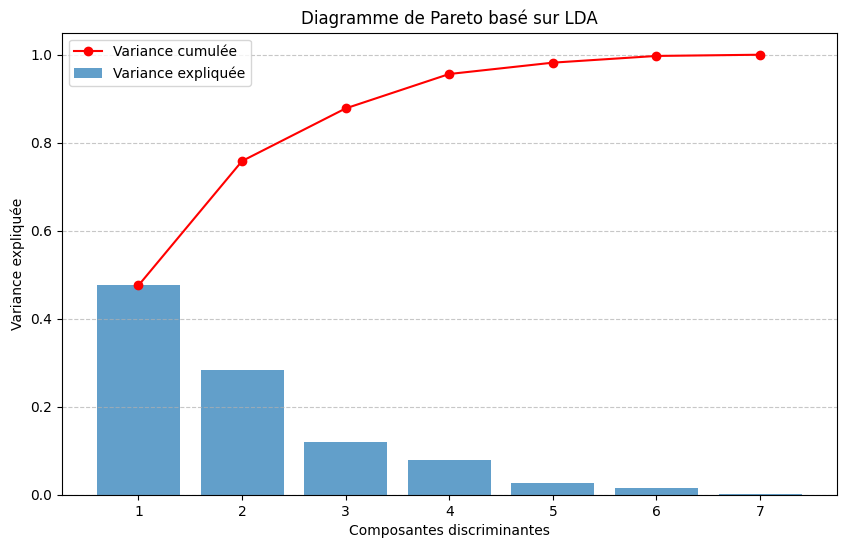

In [21]:

############  ALD ###########


lda = LinearDiscriminantAnalysis() 

# Sélectionner uniquement les colonnes numériques (exclure 'Classe', 'SousClasse', 'Numero')
X1_num = X1.select_dtypes(include=[np.number]).columns.tolist()
if 'Numero' in X1_num:
    X1_num.remove('Numero')

# Appliquer LDA
coord_lda = lda.fit_transform(X1[X1_num], y_encoded)

# Calculer la variance expliquée par chaque composante discriminante
explained_variance_ratio = lda.explained_variance_ratio_

# Créer un diagramme de Pareto
sorted_indices = np.argsort(explained_variance_ratio)[::-1]
sorted_variance = explained_variance_ratio[sorted_indices]
cumulative_variance = np.cumsum(sorted_variance)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(sorted_variance) + 1), sorted_variance, alpha=0.7, label='Variance expliquée')
plt.plot(range(1, len(sorted_variance) + 1), cumulative_variance, marker='o', color='r', label='Variance cumulée')

plt.xlabel('Composantes discriminantes')
plt.ylabel('Variance expliquée')
plt.title('Diagramme de Pareto basé sur LDA')
plt.xticks(range(1, len(sorted_variance) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

avec deux variables on n'aurait que 70% de précision, donc on a besoin de plus
au moins 5 ou 6 composantes discriminantes au minimum

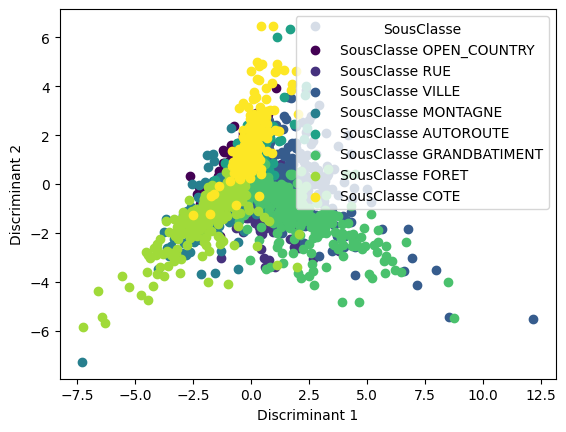

In [22]:
plt.figure()

# Création d'une palette de couleurs, juste esthétique
unique_codes = X1['SousClasse'].unique()
colors = cm.viridis(np.linspace(0, 1, len(unique_codes)))  # Génère des couleurs distinctes
color_map = dict(zip(unique_codes, colors))  # Associe chaque code à une couleur

# Tracé des points avec les couleurs correspondantes
for SousClasse in unique_codes:
    mask = X1['SousClasse'] == SousClasse
    plt.scatter(coord_lda[mask, 0], coord_lda[mask, 1], color=color_map[SousClasse], label=f'SousClasse {SousClasse}')     #on sélectionne les composantes discriminantes 1 et 2

# Ajout des étiquettes et de la légende
plt.xlabel('Discriminant 1')
plt.ylabel('Discriminant 2')
plt.legend(title='SousClasse')
plt.show()

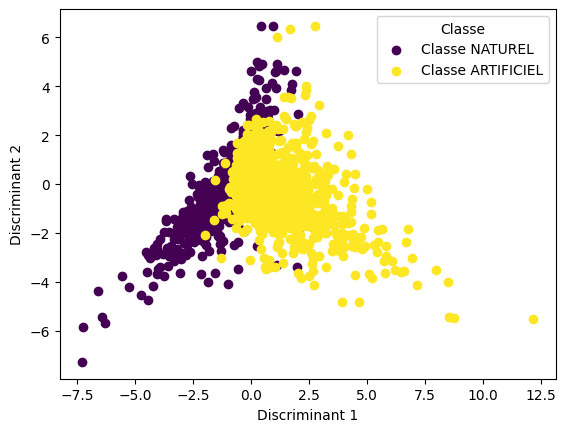

In [23]:
plt.figure()

# Création d'une palette de couleurs, juste esthétique
unique_codes = X1['Classe'].unique()
colors = cm.viridis(np.linspace(0, 1, len(unique_codes)))  # Génère des couleurs distinctes
color_map = dict(zip(unique_codes, colors))  # Associe chaque code à une couleur

# Tracé des points avec les couleurs correspondantes
for Classe in unique_codes:
    mask = X1['Classe'] == Classe
    plt.scatter(coord_lda[mask, 0], coord_lda[mask, 1], color=color_map[Classe], label=f'Classe {Classe}')     #on sélectionne les composantes discriminantes 1 et 2

# Ajout des étiquettes et de la légende
plt.xlabel('Discriminant 1')
plt.ylabel('Discriminant 2')
plt.legend(title='Classe')
plt.show()

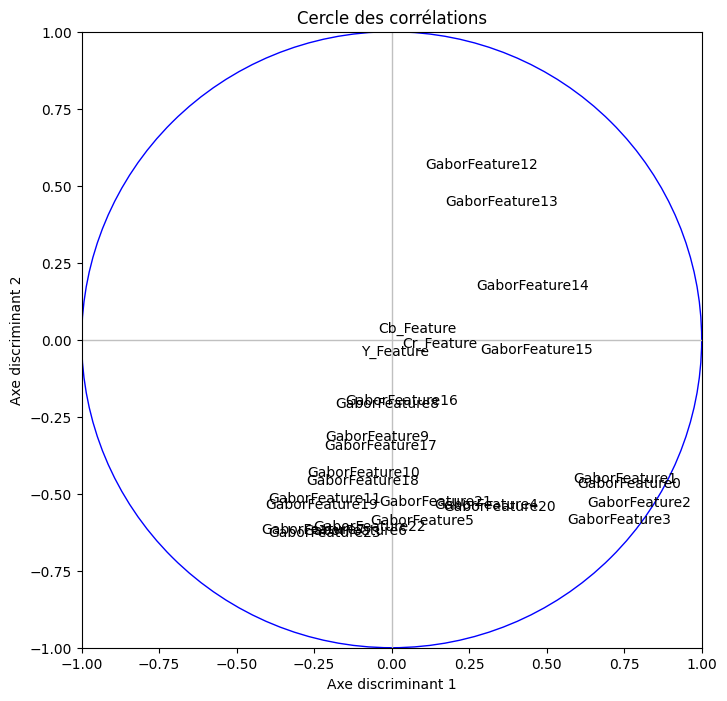

In [24]:
# Cercle des corrélations
fig, axes = plt.subplots(figsize=(8, 8))
axes.set_xlim(-1, 1)
axes.set_ylim(-1, 1)

# Calcul des corrélations entre les variables et les axes discriminants
# On utilise uniquement les features numériques (celles utilisées dans LDA)
for i, feature in enumerate(X1_num):
    # Calcul des coordonnées des variables sur le cercle
    x_corr = np.corrcoef(X1[feature], coord_lda[:, 0])[0, 1]
    y_corr = np.corrcoef(X1[feature], coord_lda[:, 1])[0, 1]
    
    # Affichage des noms des variables
    plt.annotate(feature, (x_corr, y_corr))

# Ajout des axes
plt.plot([-1, 1], [0, 0], color='silver', linestyle='-', linewidth=1)
plt.plot([0, 0], [-1, 1], color='silver', linestyle='-', linewidth=1)

# Ajout du cercle
cercle = plt.Circle((0, 0), 1, color='blue', fill=False)
axes.add_artist(cercle)

# Titres et affichage
plt.title("Cercle des corrélations")
plt.xlabel("Axe discriminant 1")
plt.ylabel("Axe discriminant 2")
plt.grid(False)
plt.show()

In [25]:
# Charger la base de données
database = pd.read_csv('./database.csv')

# Encoder les classes en valeurs numériques
yt = le.fit_transform(database['Classe'])

# On exclut 'Numero', 'Classe' et 'SousClasse'
feature_cols = [col for col in database.columns if col not in ['Numero', 'Classe', 'SousClasse']]
X = database[feature_cols].values

# Split train/test pour créer l'entrainement et le test
X_train, X_test, y_train, y_test = train_test_split(X, yt, test_size=0.2)


In [26]:
# Supposons que X_train_sous_classe et y_train_sous_classe existent

# 1. Définir le modèle et la grille de paramètres
mlpc = MLPC(max_iter=1000, random_state=42) # Ajout du random_state pour la reproductibilité
params = {
    "hidden_layer_sizes": [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    "activation": ('identity', 'logistic', 'tanh', 'relu')
}

# 2. Configurer le GridSearchCV
# Notez le cv=5 et scoring='balanced_accuracy' ICI
gridSearchClassifier = GridSearchCV(
    mlpc,
    params,
    verbose=4,
    return_train_score=True,
    n_jobs=-1,  # Utilise tous les processeurs
    cv=5,       # C'est ICI qu'on définit la validation croisée
    scoring='balanced_accuracy'
)

# 3. Lancer la recherche des meilleurs paramètres
print("Début du GridSearchCV...")
# On entraîne le GridSearchCV directement sur les données d'entraînement
gridSearchClassifier.fit(X_train, y_train)

print("Recherche terminée !")

# 4. Afficher les résultats
print("--- Meilleurs Résultats ---")
print(f"Meilleur score (balanced_accuracy) : {gridSearchClassifier.best_score_:.4f}")
print(f"Meilleurs paramètres : {gridSearchClassifier.best_params_}")

meilleur_modele_mlpc = gridSearchClassifier.best_estimator_

y_pred = meilleur_modele_mlpc.predict(X_test)
print("Classification Report :\n", classification_report(y_test, y_pred))


Début du GridSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Recherche terminée !
--- Meilleurs Résultats ---
Meilleur score (balanced_accuracy) : 0.9187
Meilleurs paramètres : {'activation': 'logistic', 'hidden_layer_sizes': 40}
Classification Report :
               precision    recall  f1-score   support

           0       0.93      0.85      0.89       251
           1       0.88      0.95      0.91       287

    accuracy                           0.90       538
   macro avg       0.91      0.90      0.90       538
weighted avg       0.91      0.90      0.90       538

Recherche terminée !
--- Meilleurs Résultats ---
Meilleur score (balanced_accuracy) : 0.9187
Meilleurs paramètres : {'activation': 'logistic', 'hidden_layer_sizes': 40}
Classification Report :
               precision    recall  f1-score   support

           0       0.93      0.85      0.89       251
           1       0.88      0.95      0.91       287

    accuracy                      

c:\Users\prich\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


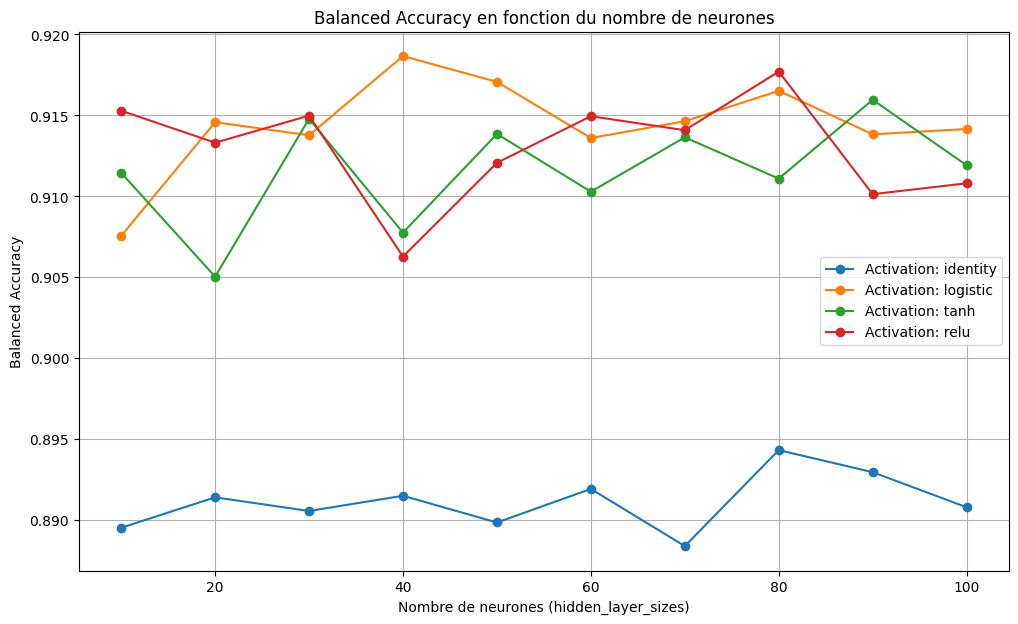

In [ ]:
# Visualisation de l'évolution de la performance en fonction du nombre de neurones
# On récupère les résultats du GridSearch stockés dans cv_results_
results_df = pd.DataFrame(gridSearchClassifier.cv_results_)

plt.figure(figsize=(12, 7))

# On trace une courbe pour chaque fonction d'activation testée
for activation in results_df['param_activation'].unique():
    # Filtrer les résultats pour l'activation courante
    subset = results_df[results_df['param_activation'] == activation]
    
    # S'assurer que les données sont triées par nombre de neurones pour le tracé
    # Note : param_hidden_layer_sizes contient ici des entiers (ex: 10, 20...)
    subset = subset.sort_values(by='param_hidden_layer_sizes')
    
    plt.plot(subset['param_hidden_layer_sizes'], subset['mean_test_score'], marker='o', label=f'Activation: {activation}')

plt.title("Balanced Accuracy en fonction du nombre de neurones")
plt.xlabel("Nombre de neurones dans la couche cachée")
plt.ylabel("Balanced Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
################# SVM ###################

# Définir la grille de paramètres pour le SVM
svc = SVC(kernel='linear')
param_grid = {
    'C': [0.1, 1, 10, 100, 1000, 10000],
    'kernel': ['linear', 'rbf', 'poly']
}

# GridSearchCV pour trouver les meilleurs paramètres
grid_svc = GridSearchCV(
    svc, 
    param_grid, 
    cv=5, 
    scoring='balanced_accuracy',
    n_jobs=-1,  # Utilise tous les processeurs, plus rapide
    verbose=2
)

grid_svc.fit(X_train, y_train)

print(f"Meilleurs paramètres SVM: {grid_svc.best_params_}")
print(f"Meilleur score: {grid_svc.best_score_:.4f}")

# Utiliser le meilleur modèle
svc = grid_svc.best_estimator_

# Apprentissage de la règle de décision sur les 27 features

svc.fit(X_train, y_train)

# Prédiction
y_pred = svc.predict(X_test)

# Évaluation
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')
print('\nRapport de classification:')
print(classification_report(y_test, y_pred, target_names=le.classes_))      #permet de voir la précision de y_pred par rapport à y_test

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, normalize='true') * 100
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Matrice de confusion - SVM (27 features)')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')

# Ajouter les valeurs dans chaque case
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], '.2f'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# Informations sur le modèle
print(f'\nNombre de vecteurs supports: {len(svc.support_vectors_)}')
print(f'Nombre de features utilisées: {X.shape[1]}')

# Visualisation sur les 2 premières composantes LDA (pour visualisation uniquement)
Xs = coord_lda[:, :2]
svc_viz = SVC(C=10000, kernel='linear')
svc_viz.fit(Xs, yt)

plt.figure(figsize=(10, 8))
x_min, x_max = Xs[:, 0].min() - 1, Xs[:, 0].max() + 1
y_min, y_max = Xs[:, 1].min() - 1, Xs[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = svc_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(Xs[:,0], Xs[:,1], c=yt, marker='o', cmap='viridis', edgecolors='k', s=50)
plt.scatter(svc_viz.support_vectors_[:,0], svc_viz.support_vectors_[:,1], 
            c='r', marker='*', s=200, label='Vecteurs supports', edgecolors='black')
plt.xlabel('Composante LDA 1')
plt.ylabel('Composante LDA 2')
plt.title('Frontière de décision SVM (projection LDA)')
plt.legend()
plt.show()

Fitting 5 folds for each of 18 candidates, totalling 90 fits


KeyboardInterrupt: 

In [ ]:
# Partie 1.2
utils.show_database(database,1,2) # pour verifier les bases et afficher un exemple images


#Base_im,label1,label2,Caract=utils.lire_images_et_carac("./images",'./database.csv',2688,sous_ech=2)

# with open('data.tout_128', 'wb') as f:
#     pickle.dump([Base_im,label1,label2,Caract],f)

# # Pour charger toutes les données de la base "à la matlab" comme un load
# # Ca suppose que le fichier data.pickle a déjà été fait
 
with open('data.tout_128', 'rb') as f:
    Base_im, label1, label2,caract = pickle.load(f)

Base_im=np.array(Base_im)   
caract=np.array(caract) 
    
Base_im=(Base_im/255)-0.5


Base_tot=list(zip(Base_im, caract))

datatrain, datatest, datalabeltrain, datalabeltest = train_test_split(Base_tot, label2-2, test_size=0.2, random_state=None)

imtrain,caractrain=zip(*datatrain)
imtest,caractest=zip(*datatest)


mc=[]
titre=[]
report=[]
resu_acc=[]
resu_acc_class=[]
int_conf=[]




I=datatrain[0][0]
(img_width, img_height, nb_plan)=np.shape(I)

#vérification pour que les entrées du réseau soient correctes
if K.image_data_format() == 'channels_first': 
    input_shape = (3, img_width, img_height) 
else: 
    input_shape = (img_width, img_height, 3) 
    
imdata=[]
imdata2=[]
for i in np.arange(len(datalabeltrain)):
    imdata.append(datatrain[i][0])
for i in np.arange(len(datalabeltest)):   
    imdata2.append(datatest[i][0])
imdatatrain=np.array(imdata)
imdatatest=np.array(imdata2)



#############################################################################################################
# Le transfert learning
#############################################################################################################

###################################################################################################################################
# CNN definition transfert learning
# load model without classifier layers
    
base_model= VGG16(include_top=False, input_shape=input_shape) #choisir la taille qui correspond à la taille des images étudiées
#base_model = InceptionV3(weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x = base_model.output
x=Flatten()(x) #pour VGG16
#x = GlobalAveragePooling2D()(x) # A la place de Flatten()
# let's add a fully-connected layer
x = Dense(500, activation='relu')(x)
x = Dropout(0.2)(x)
#x = Dense(20, activation='relu')(x)
# and a logistic layer -- On a 8 classes en sortie
predictions = Dense(8, activation='softmax')(x)


# this is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)

#####################################################################################################################
#Etape de fine-Tuning

#Pour inception
#Nbr_couches_gelees=249

#Pour VGG16
Nbr_couches_gelees=18
#####################################################################################################################

for layer in model.layers[:Nbr_couches_gelees]:
    layer.trainable = False
for layer in model.layers[Nbr_couches_gelees:]:
    layer.trainable = True

# on recompile le nouveau modèle
#model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=['accuracy'])
model.compile(optimizer='sgd', loss='categorical_crossentropy',metrics=['accuracy'])
n_epochs=3
  #nombre epoch pour le fine-tuning 
 

H=model.fit(
            imdatatrain, to_categorical(datalabeltrain),
            epochs=n_epochs,
            validation_split=0.3, verbose=1) #ici verbose = 2 
    #pour pouvoir ressortir les informations de loss et d'accuracy 
    #dans une variable obtenue avec la methode history : H.history
print(H.history)



N = np.arange(0, n_epochs)
plt.figure()
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.legend(loc="lower left")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.title("Training Loss on Dataset")
  

labels_predit = model.predict(imdatatest)


mc.append(confusion_matrix(datalabeltest,np.argmax(labels_predit,axis=1)))


acc=balanced_accuracy_score(datalabeltest, np.argmax(labels_predit,axis=1))
resu_acc.append(acc)
titre.append(f'Transfert avec Inception, accuracy={acc:.2f}]')
resu=classification_report(datalabeltest,np.argmax(labels_predit,axis=1),target_names=['2','3','4','5','6','7','8','9'],output_dict=True)
report.append(classification_report(datalabeltest,np.argmax(labels_predit,axis=1),target_names=['2','3','4','5','6','7','8','9'],output_dict=True))

acc_class=np.arange(8)*0.0
for i in np.arange(0,8):
    acc_class[i]=np.around(resu[str(i+2)]['precision'],3)
resu_acc_class.append(acc_class)


Contenu Total: 2688
Classée Artificielle: 1216
Classée Naturelle: 1472
Classée Côte: 360
Classée Forêt: 328
Classée Autoroute: 260
Classée Ville: 308
Classée Montagne: 374
Classée Paysage Ouvert: 410
Classée Rue: 292
Classée Grand Batiment: 356
 


FileNotFoundError: [Errno 2] No such file or directory: 'data.tout_128'